In [ ]:
!nvidia-smi

Mon Mar  2 09:02:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             39W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install kaggle

In [ ]:
!ls

bdd_seg_subset	bdd_yolo  runs	       yolo26n.pt
bdd_subset	drive	  sample_data  yolov8n.pt


In [ ]:
!ls -R | head -100

.:
bdd_seg_subset
bdd_subset
bdd_yolo
drive
runs
sample_data
yolo26n.pt
yolov8n.pt

./bdd_seg_subset:
images
masks
test
train

./bdd_seg_subset/images:
train
val

./bdd_seg_subset/images/train:
0004a4c0-d4dff0ad.jpg
00054602-3bf57337.jpg
0010bf16-a457685b.jpg
001c2a14-c7138401.jpg
0024b742-acbefa1a.jpg
0027eed2-09c90001.jpg
0027eed2-815a0000.jpg
0027eed2-a6630000.jpg
0027eed2-a6630001.jpg
002a3213-ab7f6730.jpg
002bf392-acddbad2.jpg
002d467e-00000000.jpg
003ddde7-36ee8299.jpg
004071a4-049be89b.jpg
004af474-00000000.jpg
00a360bd-27ccb1dd.jpg
00a395fe-d60c0b47.jpg
00a7ef03-00000000.jpg
00ad8a92-c4851839.jpg
00bc0319-94afabc2.jpg
00cc68dd-3d50a55f.jpg
00d79c0a-23befe54.jpg
00de5508-00000000.jpg
00de601c-858a8a8d.jpg
00e9be89-00000110.jpg
00e9be89-00000115.jpg
00e9be89-00000140.jpg
00e9be89-00000145.jpg
00e9be89-00000150.jpg
00e9be89-00000160.jpg
00e9be89-00000175.jpg
00e9be89-00001005.jpg
00e9be89-00001010.jpg
00e9be89-00001025.jpg
00e9be89-00001030.jpg
00e9be89-00001035.jpg
00e9be89-00001

In [ ]:
import kagglehub

path = kagglehub.dataset_download("solesensei/solesensei_bdd100k")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'solesensei_bdd100k' dataset.
Path to dataset files: /kaggle/input/solesensei_bdd100k


In [ ]:
import os

print(os.listdir(path))

['bdd100k_labels_release', 'bdd100k_seg', 'bdd100k']


In [ ]:
print(path)
import os
os.listdir(path)

/kaggle/input/solesensei_bdd100k


['bdd100k_labels_release', 'bdd100k_seg', 'bdd100k']

In [ ]:
deep_path = os.path.join(path, "bdd100k", "bdd100k")
print(os.listdir(deep_path))

['images']


In [ ]:
train_images_path = os.path.join(path, "bdd100k", "bdd100k", "images", "100k", "train")
val_images_path   = os.path.join(path, "bdd100k", "bdd100k", "images", "100k", "val")

print("Train images:", len(os.listdir(train_images_path)))
print("Val images:", len(os.listdir(val_images_path)))

Train images: 1160
Val images: 10000


In [ ]:
import os
import random
import shutil

# Paths
train_dir = train_images_path
val_dir   = val_images_path

subset_train_dir = "/content/bdd_subset/train"
subset_test_dir  = "/content/bdd_subset/test"

os.makedirs(subset_train_dir, exist_ok=True)
os.makedirs(subset_test_dir, exist_ok=True)

# Function to get only image files
def get_image_files(folder):
    return [f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Get only images
train_images = get_image_files(train_dir)
val_images   = get_image_files(val_dir)

print("Actual train image files:", len(train_images))
print("Actual val image files:", len(val_images))

# Select 840 from val for training
val_for_train = random.sample(val_images, 840)

# Remaining val images for test
remaining_val = list(set(val_images) - set(val_for_train))
val_for_test  = random.sample(remaining_val, 400)

# Copy train images (all)
for img in train_images:
    shutil.copy(os.path.join(train_dir, img), subset_train_dir)

# Copy extra 840 from val
for img in val_for_train:
    shutil.copy(os.path.join(val_dir, img), subset_train_dir)

# Copy 400 test images
for img in val_for_test:
    shutil.copy(os.path.join(val_dir, img), subset_test_dir)

print("✅ Done!")
print("Train images:", len(os.listdir(subset_train_dir)))
print("Test images:", len(os.listdir(subset_test_dir)))

Actual train image files: 1156
Actual val image files: 10000
✅ Done!
Train images: 4122
Test images: 1512


In [ ]:
deep_label_path = os.path.join(path, "bdd100k_labels_release", "bdd100k")
print(os.listdir(deep_label_path))

['labels']


In [ ]:
for root, dirs, files in os.walk(deep_label_path):
    for file in files:
        if file.endswith(".json"):
            print(os.path.join(root, file))

/kaggle/input/solesensei_bdd100k/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_val.json
/kaggle/input/solesensei_bdd100k/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_train.json


In [ ]:
for root, dirs, files in os.walk(deep_label_path):
    for file in files:
        if file.endswith(".json"):
            print(os.path.join(root, file))

/kaggle/input/solesensei_bdd100k/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_val.json
/kaggle/input/solesensei_bdd100k/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_train.json


In [ ]:
train_json_path = "/root/.cache/kagglehub/datasets/solesensei/solesensei_bdd100k/versions/2/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_train.json"

val_json_path = "/root/.cache/kagglehub/datasets/solesensei/solesensei_bdd100k/versions/2/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_val.json"

In [ ]:
import json

with open(train_json_path, "r") as f:
    train_annotations = json.load(f)

with open(val_json_path, "r") as f:
    val_annotations = json.load(f)

print("Train annotations:", len(train_annotations))
print("Val annotations:", len(val_annotations))

Train annotations: 69863
Val annotations: 10000


In [ ]:
train_subset_images = set(os.listdir("/content/bdd_subset/train"))
test_subset_images  = set(os.listdir("/content/bdd_subset/test"))

print(len(train_subset_images), len(test_subset_images))

4122 1512


In [ ]:
filtered_train_annotations = [
    ann for ann in train_annotations + val_annotations
    if ann["name"] in train_subset_images
]

filtered_test_annotations = [
    ann for ann in val_annotations
    if ann["name"] in test_subset_images
]

print("Filtered train annotations:", len(filtered_train_annotations))
print("Filtered test annotations:", len(filtered_test_annotations))

Filtered train annotations: 4120
Filtered test annotations: 1512


In [ ]:
os.makedirs("/content/bdd_subset/annotations", exist_ok=True)

with open("/content/bdd_subset/annotations/det_train_2000.json", "w") as f:
    json.dump(filtered_train_annotations, f)

with open("/content/bdd_subset/annotations/det_test_400.json", "w") as f:
    json.dump(filtered_test_annotations, f)

print("✅ Annotation subset created successfully!")

✅ Annotation subset created successfully!


In [ ]:
!pip install ultralytics

In [ ]:
import os
import json

# Paths
train_json = "/content/bdd_subset/annotations/det_train_2000.json"
test_json  = "/content/bdd_subset/annotations/det_test_400.json"

train_images = "/content/bdd_subset/train"
test_images  = "/content/bdd_subset/test"

yolo_root = "/content/bdd_yolo"

os.makedirs(yolo_root + "/images/train", exist_ok=True)
os.makedirs(yolo_root + "/images/val", exist_ok=True)
os.makedirs(yolo_root + "/labels/train", exist_ok=True)
os.makedirs(yolo_root + "/labels/val", exist_ok=True)

# Copy images
import shutil
for img in os.listdir(train_images):
    shutil.copy(os.path.join(train_images, img),
                yolo_root + "/images/train")

for img in os.listdir(test_images):
    shutil.copy(os.path.join(test_images, img),
                yolo_root + "/images/val")

print("Images copied")

Images copied


In [ ]:
from PIL import Image

def convert_bdd_to_yolo(json_file, image_folder, label_folder):
    with open(json_file) as f:
        data = json.load(f)

    for item in data:
        image_name = item["name"]
        labels = item.get("labels", [])

        img_path = os.path.join(image_folder, image_name)
        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path)
        w, h = img.size

        yolo_lines = []

        for obj in labels:
            if "box2d" not in obj:
                continue

            category = obj["category"]

            # Simple category indexing (you can refine later)
            class_id = 0

            box = obj["box2d"]
            x1, y1 = box["x1"], box["y1"]
            x2, y2 = box["x2"], box["y2"]

            xc = ((x1 + x2) / 2) / w
            yc = ((y1 + y2) / 2) / h
            bw = (x2 - x1) / w
            bh = (y2 - y1) / h

            yolo_lines.append(f"{class_id} {xc} {yc} {bw} {bh}")

        label_path = os.path.join(label_folder, image_name.replace(".jpg", ".txt"))
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_lines))


convert_bdd_to_yolo(train_json,
                    yolo_root + "/images/train",
                    yolo_root + "/labels/train")

convert_bdd_to_yolo(test_json,
                    yolo_root + "/images/val",
                    yolo_root + "/labels/val")

print("YOLO labels created")

YOLO labels created


In [ ]:
'''yaml_content = """
path: /content/bdd_yolo
train: images/train
val: images/val

nc: 1
names: ['object']
"""

with open("/content/bdd_yolo/dataset.yaml", "w") as f:
    f.write(yaml_content)

print("dataset.yaml created")'''

'yaml_content = """\npath: /content/bdd_yolo\ntrain: images/train\nval: images/val\n\nnc: 1\nnames: [\'object\']\n"""\n\nwith open("/content/bdd_yolo/dataset.yaml", "w") as f:\n    f.write(yaml_content)\n\nprint("dataset.yaml created")'

In [ ]:
'''from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/bdd_yolo/dataset.yaml",
    epochs=20,
    imgsz=640
)'''

'from ultralytics import YOLO\n\nmodel = YOLO("yolov8n.pt")\n\nmodel.train(\n    data="/content/bdd_yolo/dataset.yaml",\n    epochs=20,\n    imgsz=640\n)'

In [ ]:
model.predict(
    source="/content/bdd_yolo/images/val",
    save=True
)

NameError: name 'model' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import shutil
shutil.copy(
    "runs/detect/train/weights/best.pt",
    "/content/drive/MyDrive/bdd_project_best.pt"
)

In [ ]:
shutil.copytree(
    "/content/bdd_subset",
    "/content/drive/MyDrive/bdd_subset_backup"
)

shutil.copytree(
    "/content/bdd_seg_subset",
    "/content/drive/MyDrive/bdd_seg_subset_backup"
)

In [ ]:
seg_root = os.path.join(path, "bdd100k_seg", "bdd100k", "seg")
print(os.listdir(seg_root))

['labels', 'color_labels', 'images']


In [ ]:
seg_train_path = os.path.join(seg_root, "labels", "train")
seg_val_path   = os.path.join(seg_root, "labels", "val")

print("Train masks:", len(os.listdir(seg_train_path)))
print("Val masks:", len(os.listdir(seg_val_path)))

Train masks: 7000
Val masks: 1000


In [ ]:
import shutil
import os

seg_subset_train = "/content/bdd_seg_subset/train"
seg_subset_test  = "/content/bdd_seg_subset/test"

os.makedirs(seg_subset_train, exist_ok=True)
os.makedirs(seg_subset_test, exist_ok=True)

train_images = os.listdir("/content/bdd_subset/train")
test_images  = os.listdir("/content/bdd_subset/test")

train_image_names = [os.path.splitext(img)[0] for img in train_images]
test_image_names  = [os.path.splitext(img)[0] for img in test_images]

copied_train = 0
copied_test = 0

# Copy train masks
for mask in os.listdir(seg_train_path):
    mask_name = os.path.splitext(mask)[0]
    if mask_name in train_image_names:
        shutil.copy(os.path.join(seg_train_path, mask), seg_subset_train)
        copied_train += 1

# Copy test masks
for mask in os.listdir(seg_val_path):
    mask_name = os.path.splitext(mask)[0]
    if mask_name in test_image_names:
        shutil.copy(os.path.join(seg_val_path, mask), seg_subset_test)
        copied_test += 1

print("Copied train masks:", copied_train)
print("Copied test masks:", copied_test)

Copied train masks: 0
Copied test masks: 0


In [ ]:
print("Sample train image:", train_images[:5])

print("\nSample mask files:")
print(os.listdir(seg_train_path)[:5])

Sample train image: ['70b50978-43952295.jpg', 'b857eb06-434af6c0.jpg', 'c1f5ccf1-3db75c28.jpg', '0c0c2d36-1ead07b3.jpg', 'b4e3e68f-3aa63f29.jpg']

Sample mask files:
['411d00f9-96d7bac3_train_id.png', '09bae00f-d54c6eea_train_id.png', '1710645f-b36fa2e7_train_id.png', '71dfad78-f08054d3_train_id.png', '001b428f-059bac33_train_id.png']


In [ ]:
seg_image_train = os.path.join(seg_root, "images", "train")
seg_image_val   = os.path.join(seg_root, "images", "val")

print("Seg Train Images:", len(os.listdir(seg_image_train)))
print("Seg Val Images:", len(os.listdir(seg_image_val)))

Seg Train Images: 7000
Seg Val Images: 1000


In [ ]:
import random
import shutil
import os

seg_subset_train_img = "/content/bdd_seg_subset/images/train"
seg_subset_train_mask = "/content/bdd_seg_subset/masks/train"

seg_subset_test_img = "/content/bdd_seg_subset/images/val"
seg_subset_test_mask = "/content/bdd_seg_subset/masks/val"

os.makedirs(seg_subset_train_img, exist_ok=True)
os.makedirs(seg_subset_train_mask, exist_ok=True)
os.makedirs(seg_subset_test_img, exist_ok=True)
os.makedirs(seg_subset_test_mask, exist_ok=True)

train_imgs = os.listdir(seg_image_train)
val_imgs   = os.listdir(seg_image_val)

train_sample = random.sample(train_imgs, 2000)
val_sample   = random.sample(val_imgs, 400)

# Copy images + masks
for img in train_sample:
    shutil.copy(os.path.join(seg_image_train, img), seg_subset_train_img)

    mask_name = img.replace(".jpg", "_train_id.png")
    mask_path = os.path.join(seg_train_path, mask_name)

    if os.path.exists(mask_path):
        shutil.copy(mask_path, seg_subset_train_mask)

for img in val_sample:
    shutil.copy(os.path.join(seg_image_val, img), seg_subset_test_img)

    mask_name = img.replace(".jpg", "_train_id.png")
    mask_path = os.path.join(seg_val_path, mask_name)

    if os.path.exists(mask_path):
        shutil.copy(mask_path, seg_subset_test_mask)

print("Segmentation subset created!")

Segmentation subset created!


In [ ]:
!pip install segmentation-models-pytorch -q

In [ ]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class BDDSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)
        self.transform = T.Compose([
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_name = img_name.replace(".jpg", "_train_id.png")
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (256, 256))

        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)


        # This line is redundant and caused the error, as it overwrites the resized mask
        # mask = cv2.imread(mask_path, 0)

        image = self.transform(image)
        mask = torch.tensor(mask, dtype=torch.long)
        mask[mask > 18] = 255

        return image, mask

In [ ]:
train_dataset = BDDSegDataset(
    "/content/bdd_seg_subset/images/train",
    "/content/bdd_seg_subset/masks/train"
)

val_dataset = BDDSegDataset(
    "/content/bdd_seg_subset/images/val",
    "/content/bdd_seg_subset/masks/val"
)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1)

In [ ]:
import segmentation_models_pytorch as smp

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.DeepLabV3(
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet", # Changed from "imagenet" to None for diagnosis
    in_channels=3,
    classes=19  # BDD has 19 semantic classes
)

model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DeepLabV3(
  (encoder): MobileNetV2Encoder(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_si

In [ ]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
import torch

for epoch in range(5):   # start small
    model.train()
    # Explicitly set all BatchNorm layers to eval mode for batch_size=1
    for m in model.modules():
        if isinstance(m, torch.nn.BatchNorm2d):
            m.eval()

    total_loss = 0
    torch.cuda.empty_cache() # Clear CUDA cache at the start of each epoch

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.8835210772136851
Epoch 2, Loss: 0.6651194131396505
Epoch 3, Loss: 0.602778495686786
Epoch 4, Loss: 0.5691437926013387
Epoch 5, Loss: 0.5410975781251546


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/bdd_project_best.pt")

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [ ]:
import random
import os

test_folder = "/content/bdd_subset/test"
test_image = random.choice(os.listdir(test_folder))

image_path = os.path.join(test_folder, test_image)
print("Testing on:", image_path)

Testing on: /content/bdd_subset/test/c31aa969-fb62cfc9.jpg


In [ ]:
results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)


image 1/1 /content/bdd_subset/test/c31aa969-fb62cfc9.jpg: 384x640 13 objects, 41.2ms
Speed: 2.3ms preprocess, 41.2ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict2


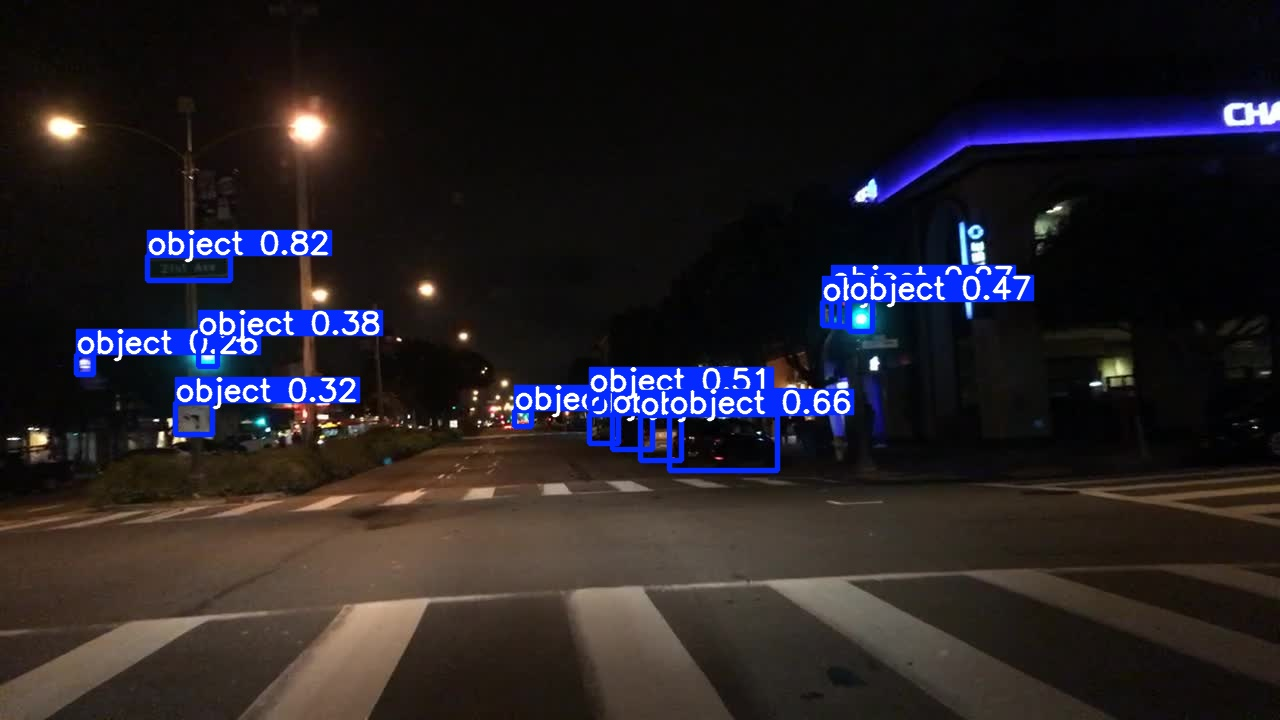

In [ ]:
from IPython.display import Image
Image(filename=results[0].save_dir + "/" + test_image)

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

img_path = image_path  # reuse same image
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_resized = cv2.resize(image, (256, 256))

tensor = torch.tensor(image_resized).permute(2,0,1).unsqueeze(0).float()/255.0
tensor = tensor.to(device)

In [ ]:
import segmentation_models_pytorch as smp

# Re-instantiate the segmentation model as the 'model' variable was overwritten by YOLO.
# Assuming `device` is defined and `smp` is imported from earlier cells.
seg_model = smp.DeepLabV3(
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=19
)
seg_model.to(device)
seg_model.eval()

with torch.no_grad():
    output = seg_model(tensor) # Use seg_model for prediction
    pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()

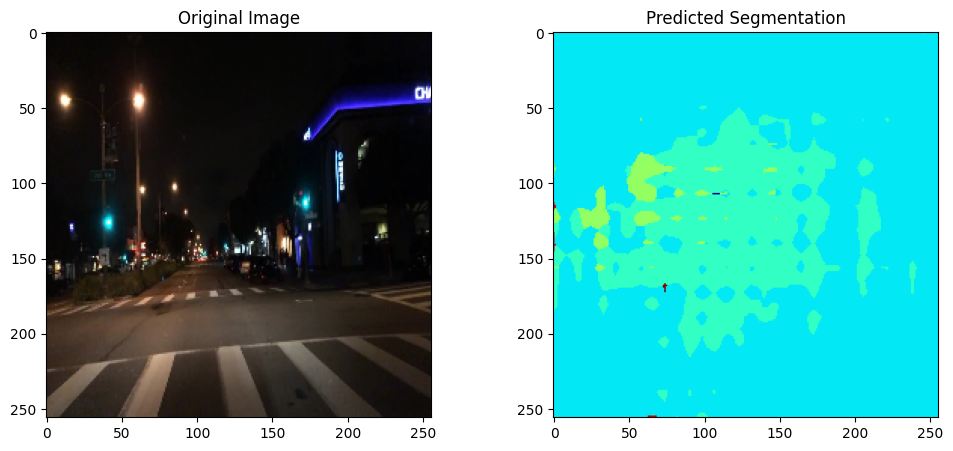

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image_resized)

plt.subplot(1,2,2)
plt.title("Predicted Segmentation")
plt.imshow(pred_mask, cmap='jet')

plt.show()

In [ ]:
import json
from collections import Counter

train_json_path = "/content/bdd_subset/annotations/det_train_2000.json"

with open(train_json_path) as f:
    train_annotations = json.load(f)

image_labels = {}

for item in train_annotations:
    name = item["name"]
    labels = item.get("labels", [])

    categories = [obj["category"] for obj in labels if "category" in obj]

    if len(categories) > 0:
        dominant = Counter(categories).most_common(1)[0][0]
        image_labels[name] = dominant

print("Total classified images:", len(image_labels))

Total classified images: 4120


In [ ]:
import json
from collections import Counter

# ---- TRAIN LABELS ----
train_json_path = "/content/bdd_subset/annotations/det_train_2000.json"

with open(train_json_path) as f:
    train_annotations = json.load(f)

image_labels = {}

for item in train_annotations:
    name = item["name"]
    labels = item.get("labels", [])

    categories = [obj["category"] for obj in labels if "category" in obj]

    if len(categories) > 0:
        dominant = Counter(categories).most_common(1)[0][0]
        image_labels[name] = dominant

print("Train labels created:", len(image_labels))


# ---- TEST LABELS ----
test_json_path = "/content/bdd_subset/annotations/det_test_400.json"

with open(test_json_path) as f:
    test_annotations = json.load(f)

test_image_labels = {}

for item in test_annotations:
    name = item["name"]
    labels = item.get("labels", [])

    categories = [obj["category"] for obj in labels if "category" in obj]

    if len(categories) > 0:
        dominant = Counter(categories).most_common(1)[0][0]
        test_image_labels[name] = dominant

print("Test labels created:", len(test_image_labels))


# ---- CLASS MAPPING ----
all_categories = set(image_labels.values()).union(set(test_image_labels.values()))
unique_classes = sorted(list(all_categories))
class_to_idx = {cls:i for i, cls in enumerate(unique_classes)}

print("Classes:", class_to_idx)

Train labels created: 4120
Test labels created: 1512
Classes: {'bike': 0, 'bus': 1, 'car': 2, 'lane': 3, 'motor': 4, 'person': 5, 'rider': 6, 'traffic light': 7, 'traffic sign': 8, 'truck': 9}


In [ ]:
all_categories = set(image_labels.values()).union(set(test_image_labels.values()))
unique_classes = sorted(list(all_categories))
class_to_idx = {cls:i for i, cls in enumerate(unique_classes)}

print("Classes:", class_to_idx)

Classes: {'bike': 0, 'bus': 1, 'car': 2, 'lane': 3, 'motor': 4, 'person': 5, 'rider': 6, 'traffic light': 7, 'traffic sign': 8, 'truck': 9}


In [ ]:
import torch
from torch.utils.data import Dataset
import cv2
import os
import torchvision.transforms as T

class BDDClassificationDataset(Dataset):
    def __init__(self, image_dir, labels_dict):
        self.image_dir = image_dir
        self.labels_dict = labels_dict
        self.images = list(labels_dict.keys())

        self.transform = T.Compose([
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))

        image = self.transform(image)

        label = class_to_idx[self.labels_dict[img_name]]
        label = torch.tensor(label)

        return image, label

In [ ]:
from torch.utils.data import DataLoader

train_dataset = BDDClassificationDataset(
    "/content/bdd_subset/train",
    image_labels
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [ ]:
all_categories = set(image_labels.values()).union(set(test_image_labels.values()))
unique_classes = sorted(list(all_categories))
class_to_idx = {cls:i for i, cls in enumerate(unique_classes)}

import torchvision.models as models
import torch.nn as nn
import torch # Added import statement for torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize without pretrained weights to debug CUDA error
model_cls = models.efficientnet_b0(pretrained=False)
model_cls.classifier[1] = nn.Linear(1280, len(unique_classes))

model_cls.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cls.parameters(), lr=1e-4)

for epoch in range(5):
    model_cls.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_cls(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}, Accuracy: {correct/total}")

Epoch 1, Loss: 1.3136944724607837, Accuracy: 0.5533980582524272
Epoch 2, Loss: 1.108071749293527, Accuracy: 0.5788834951456311
Epoch 3, Loss: 1.078755982624468, Accuracy: 0.5730582524271844
Epoch 4, Loss: 1.0336838688037193, Accuracy: 0.5878640776699029
Epoch 5, Loss: 0.9431798639454583, Accuracy: 0.6286407766990292


In [ ]:
# Load test annotation JSON
test_json_path = "/content/bdd_subset/annotations/det_test_400.json"

with open(test_json_path) as f:
    test_annotations = json.load(f)

from collections import Counter

test_image_labels = {}

for item in test_annotations:
    name = item["name"]
    labels = item.get("labels", [])

    categories = [obj["category"] for obj in labels if "category" in obj]

    if len(categories) > 0:
        dominant = Counter(categories).most_common(1)[0][0]
        test_image_labels[name] = dominant

print("Total test images with labels:", len(test_image_labels))

Total test images with labels: 1512


In [ ]:
test_dataset = BDDClassificationDataset(
    "/content/bdd_subset/test",
    test_image_labels
)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
model_cls.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_cls(images)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 0.6044973544973545


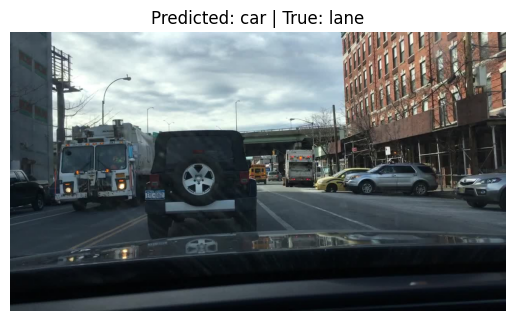

In [ ]:
import random
import matplotlib.pyplot as plt

model_cls.eval()

random_img = random.choice(list(test_image_labels.keys()))
img_path = os.path.join("/content/bdd_subset/test", random_img)

image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_resized = cv2.resize(image_rgb, (224, 224))

tensor = torch.tensor(image_resized).permute(2,0,1).unsqueeze(0).float()/255.0
tensor = tensor.to(device)

with torch.no_grad():
    output = model_cls(tensor)
    _, predicted = torch.max(output, 1)

predicted_class = unique_classes[predicted.item()]
true_class = test_image_labels[random_img]

plt.imshow(image_rgb)
plt.title(f"Predicted: {predicted_class} | True: {true_class}")
plt.axis("off")
plt.show()

In [ ]:
from ultralytics import YOLO
import torch
import segmentation_models_pytorch as smp
import torchvision.models as models
import torch.nn as nn

In [ ]:
yolo_model = YOLO("/content/drive/MyDrive/bdd_project_best.pt")

In [ ]:
torch.save(seg_model.state_dict(), "/content/drive/MyDrive/seg_model.pth")
print("Segmentation model saved successfully!")

Segmentation model saved successfully!


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

seg_model = smp.DeepLabV3(
    encoder_name="mobilenet_v2",
    encoder_weights=None,
    in_channels=3,
    classes=19
)

seg_model.load_state_dict(torch.load("/content/drive/MyDrive/seg_model.pth"))
seg_model.to(device)
seg_model.eval()

DeepLabV3(
  (encoder): MobileNetV2Encoder(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_si

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

torch.save(model_cls.state_dict(), "/content/drive/MyDrive/class_model.pth")

print("Classification model saved successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classification model saved successfully!


In [ ]:
state_dict = torch.load("/content/drive/MyDrive/class_model.pth")

print(state_dict["classifier.1.weight"].shape)

torch.Size([9, 1280])


In [ ]:
model_cls = models.efficientnet_b0(pretrained=False)
model_cls.classifier[1] = nn.Linear(1280, len(unique_classes))

model_cls.load_state_dict(torch.load("/content/drive/MyDrive/class_model.pth"))
model_cls.to(device)
model_cls.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
import random
import os

test_folder = "/content/bdd_subset/test"
img_name = random.choice(os.listdir(test_folder))
img_path = os.path.join(test_folder, img_name)

print("Testing image:", img_name)

Testing image: b6804637-851a6e28.jpg


In [ ]:
det_results = yolo_model.predict(img_path, conf=0.25)
det_img = det_results[0].plot()


image 1/1 /content/bdd_subset/test/b6804637-851a6e28.jpg: 384x640 2 objects, 58.4ms
Speed: 6.9ms preprocess, 58.4ms inference, 20.3ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
import cv2
import numpy as np

image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_seg = cv2.resize(image_rgb, (256,256))
tensor = torch.tensor(image_seg).permute(2,0,1).unsqueeze(0).float()/255.0
tensor = tensor.to(device)

with torch.no_grad():
    output = seg_model(tensor)
    pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()

In [ ]:
mask_colored = cv2.applyColorMap((pred_mask*10).astype(np.uint8), cv2.COLORMAP_JET)
mask_colored = cv2.resize(mask_colored, (image_rgb.shape[1], image_rgb.shape[0]))

seg_overlay = cv2.addWeighted(image_rgb, 0.7, mask_colored, 0.3, 0)

In [ ]:
image_cls = cv2.resize(image_rgb, (224,224))
tensor_cls = torch.tensor(image_cls).permute(2,0,1).unsqueeze(0).float()/255.0
tensor_cls = tensor_cls.to(device)

with torch.no_grad():
    output_cls = model_cls(tensor_cls)
    _, predicted = torch.max(output_cls, 1)

predicted_class = unique_classes[predicted.item()]

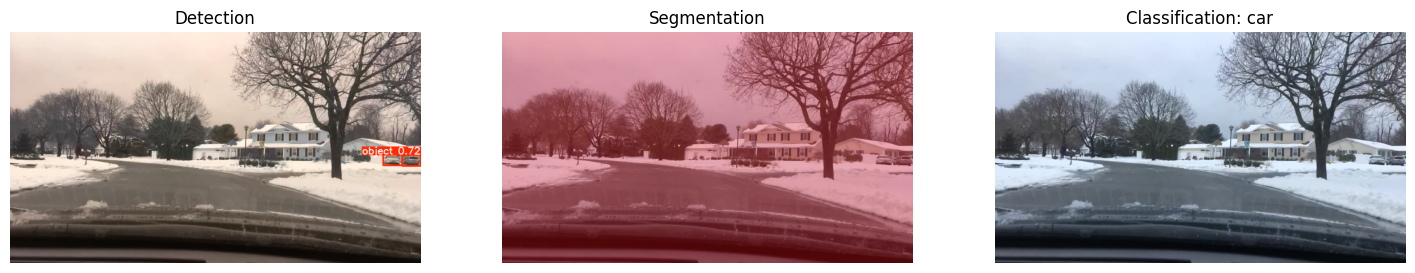

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.title("Detection")
plt.imshow(det_img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Segmentation")
plt.imshow(seg_overlay)
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"Classification: {predicted_class}")
plt.imshow(image_rgb)
plt.axis("off")

plt.show()

In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/bdd_project_best.pt")
files.download("/content/drive/MyDrive/seg_model.pth")
files.download("/content/drive/MyDrive/class_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>